https://docs.nvidia.com/deeplearning/dali/user-guide/docs/examples/general/data_loading/numpy_reader.html#GPUDirect-Storage-Support

In [1]:
import os

batch_size = 4  # to be used in pipelines
dali_extra_dir = "/home/doserbd/git/DALI_extra"
data_dir_2d = os.path.join(dali_extra_dir, "db", "3D", "MRI", "Knee", "npy_2d_slices", "STU00001")
data_dir_3d = os.path.join(dali_extra_dir, "db", "3D", "MRI", "Knee", "npy_3d", "STU00001")

In [2]:
# misc python stuff
import numpy as np

# visualization
from PIL import Image
import matplotlib.pyplot as plt


def plot_batch(np_arrays, nsamples=None):
    if nsamples is None:
        nsamples = len(np_arrays)
    fig, axvec = plt.subplots(nrows=1, ncols=nsamples, figsize=(10, 10 * nsamples))
    for i in range(nsamples):
        ax = axvec[i]
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.imshow(Image.fromarray(np_arrays[i]))
    plt.tight_layout()

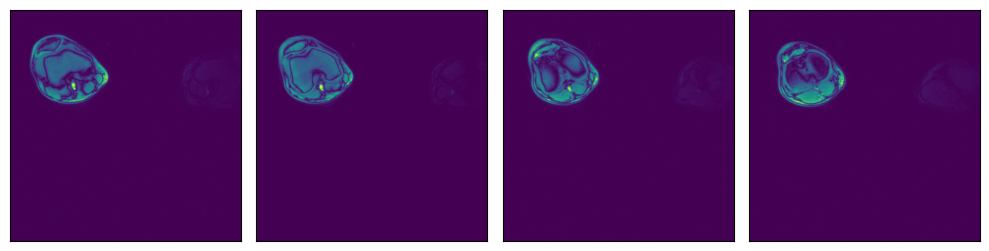

In [3]:
ser00001_2d = [np.load(os.path.join(data_dir_2d, "SER00001", f"{i}.npy")) for i in range(4)]
plot_batch(ser00001_2d)

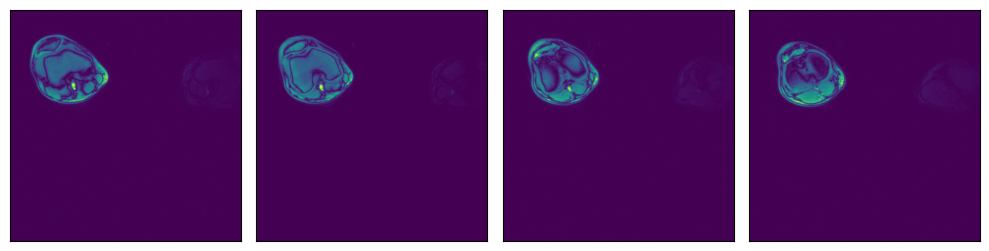

In [4]:
from nvidia.dali import pipeline_def, fn

data_dir = os.path.join(data_dir_2d, "SER00001")


@pipeline_def(batch_size=batch_size, num_threads=3, device_id=0)
def pipe1():
    data = fn.readers.numpy(device="cpu", file_root=data_dir, file_filter="*.npy")
    return data


def run(p):
    p.build()  # build the pipeline
    outputs = p.run()  # Run once
    # Getting the batch as a list of numpy arrays, for displaying
    batch = [np.array(outputs[0][s]) for s in range(batch_size)]
    return batch


data1 = run(pipe1())
plot_batch(data1)

(TensorListGPU(
    dtype=DALIDataType.UINT8,
    num_samples=4,
    shape=[(512, 512), (512, 512), (512, 512), (512, 512)]),)
(4, 512, 512)


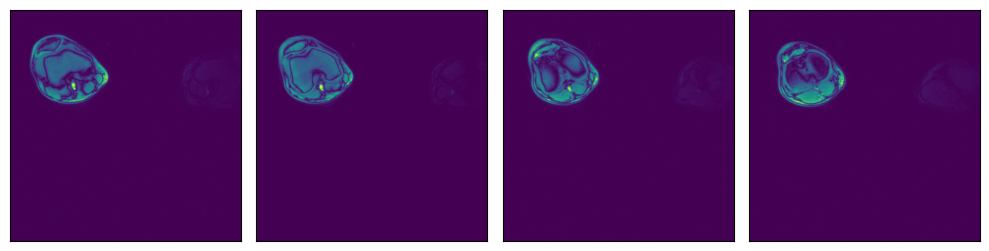

In [5]:
files = ["0.npy", "1.npy", "2.npy", "3.npy"]


@pipeline_def(batch_size=batch_size, num_threads=3, device_id=0)
def pipe_gds():
    data = fn.readers.numpy(device="gpu", file_root=data_dir, file_filter="*.npy")
    return data


p = pipe_gds()
p.build()
pipe_out = p.run()
print(pipe_out)

# as_cpu() to copy the data back to CPU memory
data_gds = pipe_out[0].as_cpu().as_array()
print(data_gds.shape)
plot_batch(data_gds)